# ⚛️ Quantum Gates

## Qiskit Quantum Learning — Module 02

Quantum gates are the fundamental operations used to manipulate
qubits.

In this notebook we will study:

- Pauli X, Y and Z gates
- Hadamard gate
- S and T phase gates
- RX, RY and RZ rotation gates
- CNOT and CZ controlled gates
- SWAP gate
- Gate combinations
- Self-inverse gates
- Statevectors
- Bloch-sphere visualization
- Quantum gate experiments

### Learning Philosophy

**Understand → Implement → Experiment → Observe → Analyze**


## 1. Import Required Libraries

We will use Qiskit to construct quantum circuits and inspect
quantum states.

We will also use NumPy for mathematical operations and
Matplotlib for visualization.

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. What Is a Quantum Gate?

A quantum gate is a mathematical operation that changes the
state of a qubit.

For example:

$$
X|0\rangle = |1\rangle
$$

The Pauli-X gate changes the qubit from `|0⟩` to `|1⟩`.

Unlike classical logic gates, quantum gates operate on
quantum states and are represented by **unitary matrices**.

A quantum gate must preserve the total probability of the
quantum state.

## 3. Common Quantum Gate Matrices

### Pauli-X

$$
X =
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$

### Pauli-Y

$$
Y =
\begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}
$$

### Pauli-Z

$$
Z =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

### Hadamard

$$
H =
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
$$

In [2]:
X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

Y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

Z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

H = (1 / np.sqrt(2)) * np.array([
    [1, 1],
    [1, -1]
], dtype=complex)

print("Pauli-X:")
print(X)

print("\nPauli-Y:")
print(Y)

print("\nPauli-Z:")
print(Z)

print("\nHadamard:")
print(H)

Pauli-X:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Pauli-Y:
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Pauli-Z:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

Hadamard:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


# 4. Pauli-X Gate

The Pauli-X gate is the quantum equivalent of a bit flip.

$$
X|0\rangle = |1\rangle
$$

$$
X|1\rangle = |0\rangle
$$

It is represented by:

$$
X =
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$

Initial circuit:


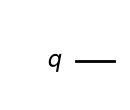

Initial state:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

After X gate:


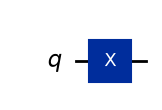

State after X:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

Probabilities:
{np.str_('1'): np.float64(1.0)}


In [3]:
qc_x = QuantumCircuit(1)

print("Initial circuit:")
display(qc_x.draw("mpl"))

state_before = Statevector.from_instruction(qc_x)

print("Initial state:")
print(state_before)

qc_x.x(0)

print("\nAfter X gate:")
display(qc_x.draw("mpl"))

state_after = Statevector.from_instruction(qc_x)

print("State after X:")
print(state_after)

print("\nProbabilities:")
print(state_after.probabilities_dict())

# 5. Pauli-Y Gate

The Pauli-Y gate changes both the computational state and
the phase.

$$
Y|0\rangle = i|1\rangle
$$

$$
Y|1\rangle = -i|0\rangle
$$

Matrix:

$$
Y =
\begin{bmatrix}
0 & -i \\
i & 0
\end{bmatrix}
$$

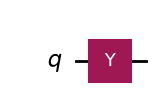

State after Y:
Statevector([0.+0.j, 0.+1.j],
            dims=(2,))

Probabilities:
{np.str_('1'): np.float64(1.0)}


In [4]:
qc_y = QuantumCircuit(1)

qc_y.y(0)

display(qc_y.draw("mpl"))

state_y = Statevector.from_instruction(qc_y)

print("State after Y:")
print(state_y)

print("\nProbabilities:")
print(state_y.probabilities_dict())

# 6. Pauli-Z Gate

The Pauli-Z gate performs a phase flip.

$$
Z|0\rangle = |0\rangle
$$

$$
Z|1\rangle = -|1\rangle
$$

Matrix:

$$
Z =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

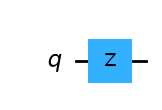

State after Z:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Probabilities:
{np.str_('0'): np.float64(1.0)}


In [5]:
qc_z = QuantumCircuit(1)

qc_z.z(0)

display(qc_z.draw("mpl"))

state_z = Statevector.from_instruction(qc_z)

print("State after Z:")
print(state_z)

print("\nProbabilities:")
print(state_z.probabilities_dict())

# 7. Hadamard Gate

The Hadamard gate is one of the most important gates in
quantum computing.

It creates a superposition.

Starting with `|0⟩`:

$$
H|0\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Therefore:

$$
P(0)=\frac{1}{2}
$$

$$
P(1)=\frac{1}{2}
$$

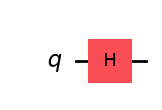

State after H:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


In [6]:
qc_h = QuantumCircuit(1)

qc_h.h(0)

display(qc_h.draw("mpl"))

state_h = Statevector.from_instruction(qc_h)

print("State after H:")
print(state_h)

print("\nProbabilities:")
print(state_h.probabilities_dict())

# 8. Phase Gates — S and T

Phase gates modify the phase of a quantum state.

### S Gate

$$
S =
\begin{bmatrix}
1 & 0 \\
0 & i
\end{bmatrix}
$$

The S gate adds a phase of:

$$
\frac{\pi}{2}
$$

### T Gate

$$
T =
\begin{bmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{bmatrix}
$$

The T gate adds a phase of:

$$
\frac{\pi}{4}
$$

S gate:


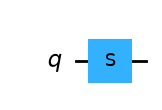

State after S:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

T gate:


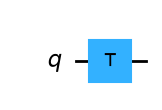

State after T:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [7]:
qc_s = QuantumCircuit(1)
qc_s.s(0)

qc_t = QuantumCircuit(1)
qc_t.t(0)

print("S gate:")
display(qc_s.draw("mpl"))

state_s = Statevector.from_instruction(qc_s)
print("State after S:")
print(state_s)

print("\nT gate:")
display(qc_t.draw("mpl"))

state_t = Statevector.from_instruction(qc_t)
print("State after T:")
print(state_t)

# 9. Rotation Gates

Rotation gates allow us to rotate a qubit state around the
axes of the Bloch sphere.

### RX

Rotation around the X-axis.

### RY

Rotation around the Y-axis.

### RZ

Rotation around the Z-axis.

We will use:

$$
\theta = \frac{\pi}{2}
$$

RX(pi/2):


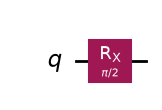

RY(pi/2):


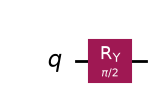

RZ(pi/2):


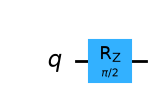

RX state:
Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))

RY state:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

RZ state:
Statevector([0.70710678-0.70710678j, 0.        +0.j        ],
            dims=(2,))


In [8]:
theta = np.pi / 2

qc_rx = QuantumCircuit(1)
qc_rx.rx(theta, 0)

qc_ry = QuantumCircuit(1)
qc_ry.ry(theta, 0)

qc_rz = QuantumCircuit(1)
qc_rz.rz(theta, 0)

print("RX(pi/2):")
display(qc_rx.draw("mpl"))

print("RY(pi/2):")
display(qc_ry.draw("mpl"))

print("RZ(pi/2):")
display(qc_rz.draw("mpl"))

state_rx = Statevector.from_instruction(qc_rx)
state_ry = Statevector.from_instruction(qc_ry)
state_rz = Statevector.from_instruction(qc_rz)

print("RX state:")
print(state_rx)

print("\nRY state:")
print(state_ry)

print("\nRZ state:")
print(state_rz)

# 10. Controlled-X / CNOT Gate

The CNOT gate operates on two qubits.

It has:

- One control qubit
- One target qubit

The X operation is applied to the target only when the
control qubit is `|1⟩`.

Circuit:

```text
q0 ──●──
     │
q1 ──X──
```

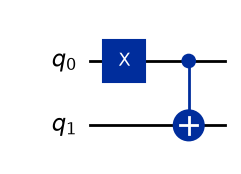

State after CNOT:
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))

Probabilities:
{np.str_('11'): np.float64(1.0)}


In [9]:
qc_cx = QuantumCircuit(2)

qc_cx.x(0)
qc_cx.cx(0, 1)

display(qc_cx.draw("mpl"))

state_cx = Statevector.from_instruction(qc_cx)

print("State after CNOT:")
print(state_cx)

print("\nProbabilities:")
print(state_cx.probabilities_dict())

# 11. Controlled-Z Gate

The CZ gate applies a Z operation when the control condition
is satisfied.

It is a two-qubit controlled phase operation.

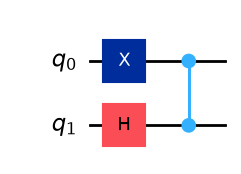

State after CZ:
Statevector([ 0.        +0.j,  0.70710678+0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

Probabilities:
{np.str_('01'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


In [10]:
qc_cz = QuantumCircuit(2)

qc_cz.x(0)
qc_cz.h(1)
qc_cz.cz(0, 1)

display(qc_cz.draw("mpl"))

state_cz = Statevector.from_instruction(qc_cz)

print("State after CZ:")
print(state_cz)

print("\nProbabilities:")
print(state_cz.probabilities_dict())

# 12. SWAP Gate

The SWAP gate exchanges the states of two qubits.

For example:

```text
|0⟩ |1⟩
 ↓   ↓
SWAP
 ↓   ↓
|1⟩ |0⟩
```

Before SWAP:


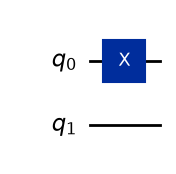

After SWAP:


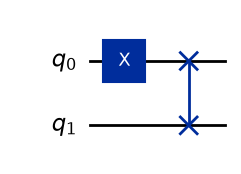

State after SWAP:
Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))

Probabilities:
{np.str_('10'): np.float64(1.0)}


In [11]:
qc_swap = QuantumCircuit(2)

qc_swap.x(0)

print("Before SWAP:")
display(qc_swap.draw("mpl"))

qc_swap.swap(0, 1)

print("After SWAP:")
display(qc_swap.draw("mpl"))

state_swap = Statevector.from_instruction(qc_swap)

print("State after SWAP:")
print(state_swap)

print("\nProbabilities:")
print(state_swap.probabilities_dict())

# 13. Gate Combinations

Quantum algorithms are built by combining quantum gates.

A useful identity is:

$$
HZH = X
$$

This means applying H, then Z, then H produces the same
operation as X.

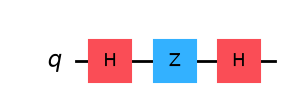

Final state:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

Probabilities:
{np.str_('1'): np.float64(0.9999999999999996)}


In [12]:
qc_combination = QuantumCircuit(1)

qc_combination.h(0)
qc_combination.z(0)
qc_combination.h(0)

display(qc_combination.draw("mpl"))

state_combination = Statevector.from_instruction(
    qc_combination
)

print("Final state:")
print(state_combination)

print("\nProbabilities:")
print(state_combination.probabilities_dict())

# 14. Self-Inverse Gates

Some quantum gates are their own inverse.

For example:

$$
X^2 = I
$$

$$
Y^2 = I
$$

$$
Z^2 = I
$$

$$
H^2 = I
$$

Therefore, applying the same gate twice returns the original
state.

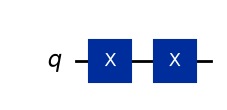

Final state after X-X:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))

Probabilities:
{np.str_('0'): np.float64(1.0)}


In [13]:
qc_inverse = QuantumCircuit(1)

qc_inverse.x(0)
qc_inverse.x(0)

display(qc_inverse.draw("mpl"))

state_inverse = Statevector.from_instruction(qc_inverse)

print("Final state after X-X:")
print(state_inverse)

print("\nProbabilities:")
print(state_inverse.probabilities_dict())

# 15. Bloch Sphere

The Bloch sphere gives us a geometric representation of a
single qubit.

Important states:

| State | Bloch Vector |
|---|---|
| `|0⟩` | `(0, 0, 1)` |
| `|1⟩` | `(0, 0, -1)` |
| `|+⟩` | `(1, 0, 0)` |
| `|−⟩` | `(-1, 0, 0)` |

The axes are:

- X-axis
- Y-axis
- Z-axis

|0>: [0, 0, 1]


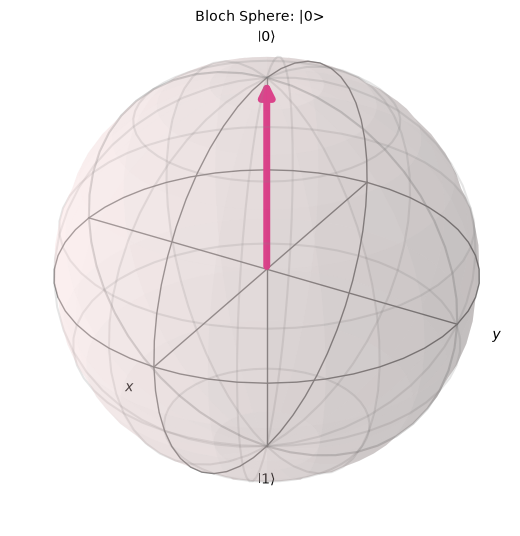

|1>: [0, 0, -1]


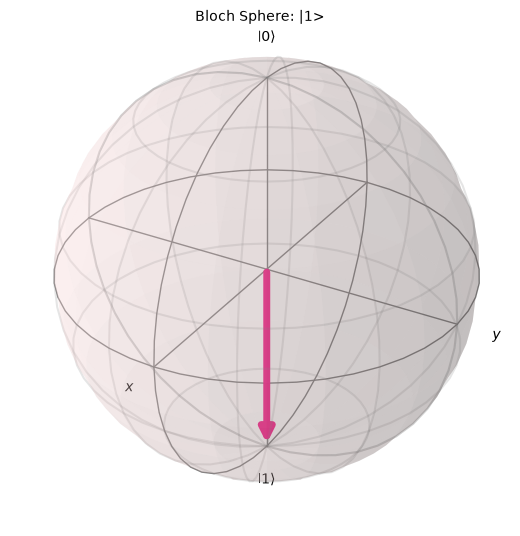

|+>: [1, 0, 0]


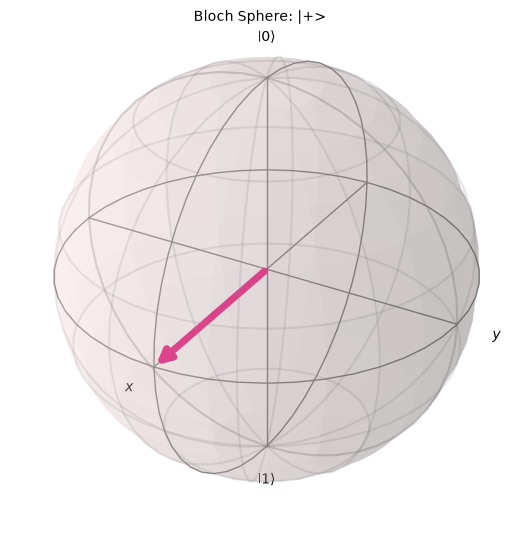

|->: [-1, 0, 0]


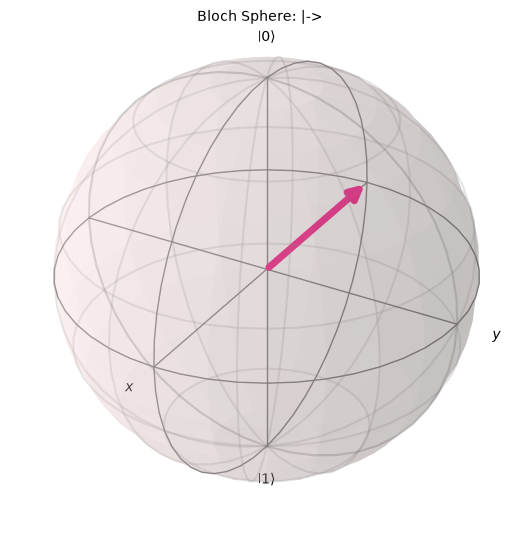

In [14]:
bloch_states = {
    "|0>": [0, 0, 1],
    "|1>": [0, 0, -1],
    "|+>": [1, 0, 0],
    "|->": [-1, 0, 0],
}

for state_name, vector in bloch_states.items():

    print(f"{state_name}: {vector}")

    fig = plot_bloch_vector(
        vector,
        title=f"Bloch Sphere: {state_name}"
    )

    display(fig)

## Pauli Gates and the Bloch Sphere

Starting from `|0⟩`:

- X moves the state to `|1⟩`
- Y also moves `|0⟩` to the same physical Bloch-sphere point,
  with a phase factor
- Z leaves `|0⟩` at the same physical point

This demonstrates an important idea:

**The Bloch sphere represents the physical qubit state,
while global phase does not change the physical state.**

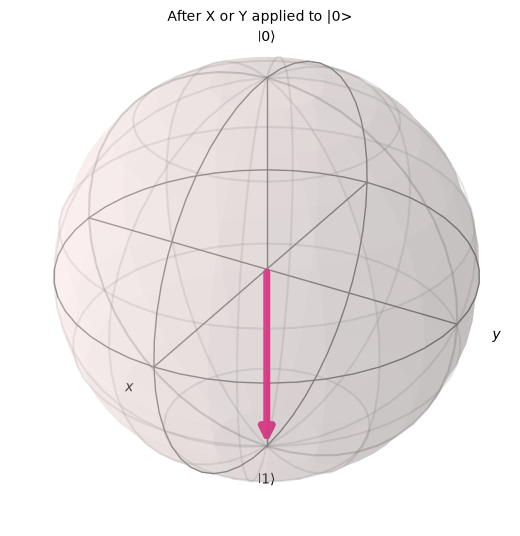

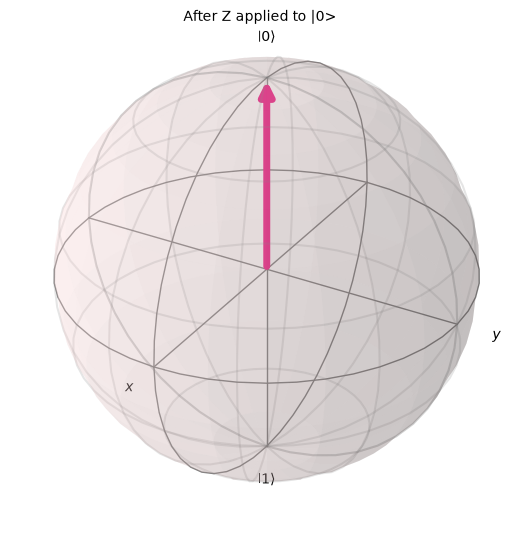

In [15]:
fig = plot_bloch_vector(
    [0, 0, -1],
    title="After X or Y applied to |0>"
)

display(fig)

fig = plot_bloch_vector(
    [0, 0, 1],
    title="After Z applied to |0>"
)

display(fig)

# 16. Quantum Gate Comparison

| Gate | Main Function |
|---|---|
| X | Bit flip |
| Y | Bit + phase transformation |
| Z | Phase flip |
| H | Creates superposition |
| S | π/2 phase |
| T | π/4 phase |
| RX | Rotation around X |
| RY | Rotation around Y |
| RZ | Rotation around Z |
| CX | Controlled-X |
| CZ | Controlled-Z |
| SWAP | Exchanges two qubit states |

# 17. Final Quantum Circuit

Let's combine several concepts into one circuit.

We will:

1. Create superposition.
2. Apply a CNOT.
3. Apply a Z gate.
4. Apply another H gate.
5. Inspect the final statevector.

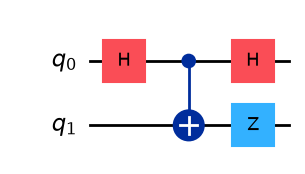

Final statevector:
Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2))

Final probabilities:
{np.str_('00'): np.float64(0.2499999999999999), np.str_('01'): np.float64(0.2499999999999999), np.str_('10'): np.float64(0.2499999999999999), np.str_('11'): np.float64(0.2499999999999999)}


In [16]:
final_circuit = QuantumCircuit(2)

final_circuit.h(0)
final_circuit.cx(0, 1)
final_circuit.z(1)
final_circuit.h(0)

display(final_circuit.draw("mpl"))

final_state = Statevector.from_instruction(final_circuit)

print("Final statevector:")
print(final_state)

print("\nFinal probabilities:")
print(final_state.probabilities_dict())

# 18. Key Takeaways

We studied the major quantum gates used in this module.

### Single-qubit gates

- Pauli-X
- Pauli-Y
- Pauli-Z
- Hadamard
- S
- T
- RX
- RY
- RZ

### Multi-qubit gates

- CNOT / CX
- CZ
- SWAP

### Important concepts

- Quantum gates transform quantum states.
- Quantum gates are represented by unitary matrices.
- The Hadamard gate creates superposition.
- Pauli gates perform bit and phase transformations.
- Rotation gates move states around the Bloch sphere.
- Controlled gates allow interactions between qubits.
- Gates can be combined to construct quantum algorithms.
- Some gates are self-inverse.
- Statevectors allow us to inspect quantum states mathematically.

### Learning Flow

```text
Quantum State
      ↓
Quantum Gate
      ↓
State Transformation
      ↓
Statevector
      ↓
Visualization / Measurement
      ↓
Observation
      ↓
Understanding